# Generalized $\beta$ Formulation for 1D Heat Equation

The 1D heat conduction equation is given by:
$$ \frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2} $$

Using a generalized $\beta$ finite difference scheme, the temporal and spatial derivatives are discretized as:
$$ \frac{T_i^{n+1} - T_i^n}{\Delta t} = \alpha \left[ \beta \frac{T_{i+1}^{n+1} - 2T_i^{n+1} + T_{i-1}^{n+1}}{\Delta x^2} + (1-\beta) \frac{T_{i+1}^n - 2T_i^n + T_{i-1}^n}{\Delta x^2} \right] $$

Let $\gamma = \frac{\alpha \Delta t}{\Delta x^2}$. Rearranging to isolate the unknown $(n+1)$ terms on the left hand side yields a tridiagonal system:
$$ -\gamma\beta T_{i-1}^{n+1} + (1+2\gamma\beta)T_i^{n+1} - \gamma\beta T_{i+1}^{n+1} = \gamma(1-\beta)T_{i-1}^n + [1-2\gamma(1-\beta)]T_i^n + \gamma(1-\beta)T_{i+1}^n $$

This system is efficiently solved in $O(N)$ time using the **Tri-Diagonal Matrix Algorithm (TDMA)**.

- **$\beta = 0.0$**: Explicit FTCS (Conditionally stable)
- **$\beta = 0.5$**: Crank-Nicolson (Unconditionally stable, 2nd order in time)
- **$\beta = 1.0$**: Laasonen / Fully Implicit (Unconditionally stable, 1st order in time)

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def solve_beta_formulation(dt, beta, target_times):
    L, alpha, nodes = 1.0, 1.0, 11
    dx = L / (nodes - 1)
    gamma = alpha * dt / dx**2
    
    # Setup TDMA LHS diagonals (a: sub, b: main, c: super)
    a = np.full(nodes - 1, -gamma * beta)
    b = np.full(nodes, 1 + 2 * gamma * beta)
    c = np.full(nodes - 1, -gamma * beta)
    
    # Apply LHS boundary conditions
    b[0], c[0] = 1.0, 0.0
    a[-1], b[-1] = 0.0, 1.0
    
    # Explicit matrix B for RHS calculation
    B = np.zeros((nodes, nodes))
    for i in range(1, nodes - 1):
        B[i, i-1] = gamma * (1 - beta)
        B[i, i]   = 1 - 2 * gamma * (1 - beta)
        B[i, i+1] = gamma * (1 - beta)
        
    x = np.linspace(0, L, nodes)
    T = np.zeros(nodes)
    T_history = {0.0: T.copy()} # Store initial state
    
    T[0], T[-1] = 1.0, 0.0
    num_steps = int(round(max(target_times) / dt))
    plot_steps = [int(round(t / dt)) for t in target_times]
    
    # TDMA Precomputations (Matrix is constant in time)
    c_prime = np.zeros(nodes - 1)
    m = np.zeros(nodes)
    m[0] = b[0]
    c_prime[0] = c[0] / m[0]
    for i in range(1, nodes - 1):
        m[i] = b[i] - a[i-1] * c_prime[i-1]
        c_prime[i] = c[i] / m[i]
    m[-1] = b[-1] - a[-1] * c_prime[-1]
    
    # Time-stepping loop
    for n in range(1, num_steps + 1):
        RHS = B @ T
        RHS[0], RHS[-1] = 1.0, 0.0
        
        # TDMA Forward Sweep
        d_prime = np.zeros(nodes)
        d_prime[0] = RHS[0] / m[0]
        for i in range(1, nodes):
            d_prime[i] = (RHS[i] - a[i-1] * d_prime[i-1]) / m[i]
            
        # TDMA Back Substitution
        T[-1] = d_prime[-1]
        for i in range(nodes - 2, -1, -1):
            T[i] = d_prime[i] - c_prime[i] * T[i+1]
        
        if n in plot_steps:
            T_history[n * dt] = T.copy()
            
    return x, T_history

def plot_results(x, T_history, dt, beta, scheme_name):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(T_history)))
    
    for i, (t, T_vals) in enumerate(T_history.items()):
        ax.plot(x, T_vals, marker='o', markersize=5, color=colors[i], label=f't = {t:g} s')
        
    ax.set_xlabel('Position (m)')
    ax.set_ylabel('Temperature')
    ax.set_title(rf'1D Heat Conduction ({scheme_name}) | $\Delta t$ = {dt} s | $\beta$ = {beta}')
    ax.legend(title='Time (s)')
    plt.show()

### 1. Explicit FTCS ($\beta = 0.0$)
Requires a very small time step (`dt=0.001`) to maintain stability ($\gamma \leq 0.5$).

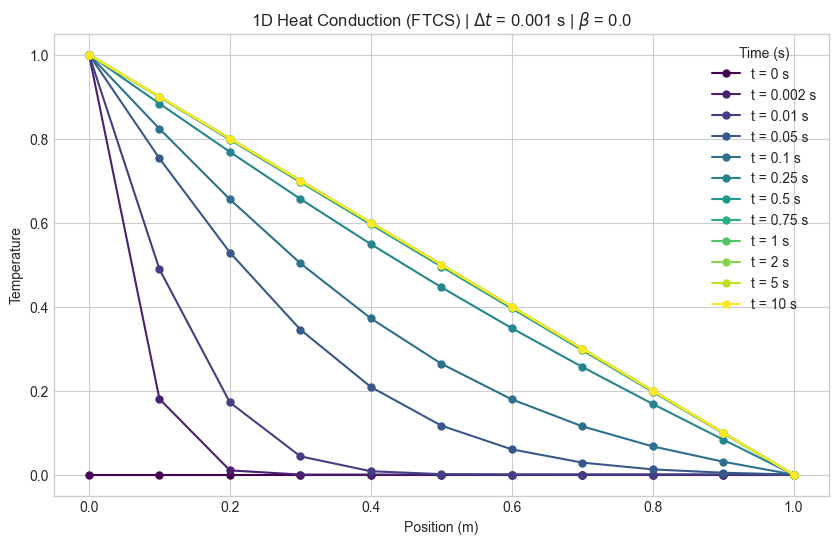

In [27]:
target_times = [0, 0.002, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0]


x, history_ftcs = solve_beta_formulation(dt=0.001, beta=0.0, target_times=target_times)
plot_results(x, history_ftcs, dt=0.001, beta=0.0, scheme_name="FTCS")

### 2. Crank-Nicolson ($\beta = 0.5$)
Unconditionally stable. We can run this safely at a large time step (`dt=0.1`).

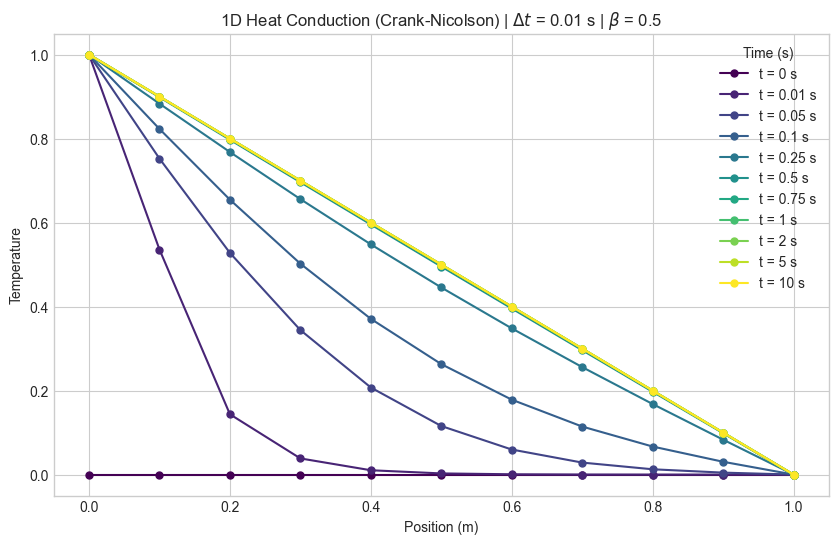

In [30]:
x, history_cn = solve_beta_formulation(dt=0.01, beta=0.5, target_times=target_times)
plot_results(x, history_cn, dt=0.01, beta=0.5, scheme_name="Crank-Nicolson")

### 3. Laasonen / Fully Implicit ($\beta = 1.0$)
Unconditionally stable. We can also run this safely at a large time step (`dt=0.1`).

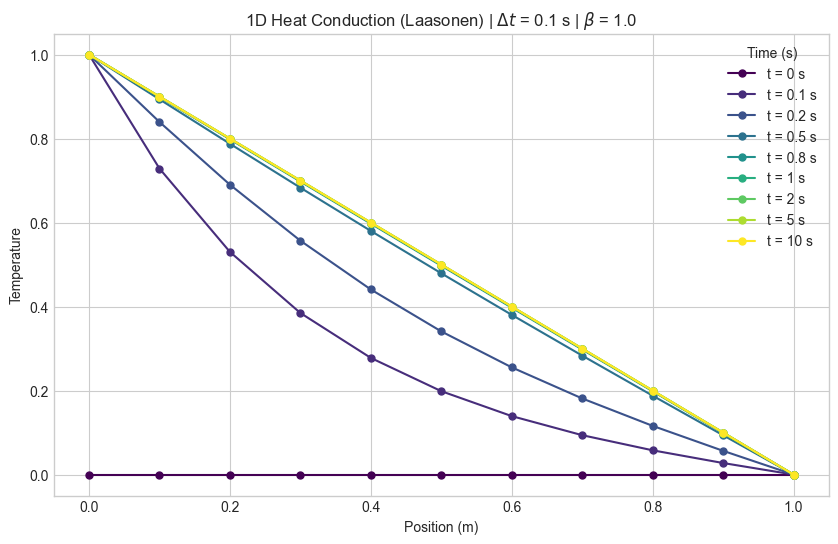

In [29]:
x, history_laasonen = solve_beta_formulation(dt=0.1, beta=1.0, target_times=target_times)
plot_results(x, history_laasonen, dt=0.1, beta=1.0, scheme_name="Laasonen")